In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [42]:
df = pd.read_csv('../Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [43]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [44]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


<Axes: xlabel='Exited', ylabel='count'>

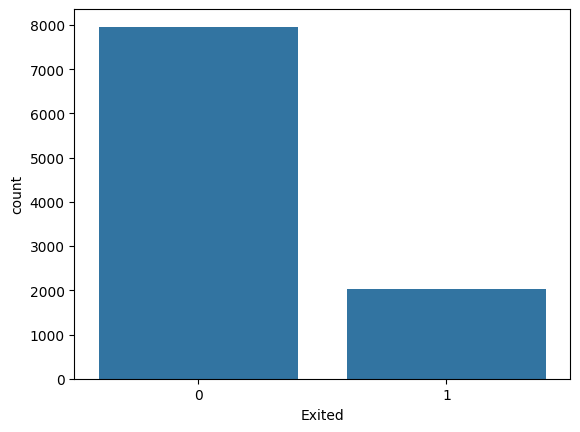

In [48]:
sns.countplot(x="Exited", data=df)

Таким образом, наблюдается несбалансированность классов.

<Axes: xlabel='Exited', ylabel='Age'>

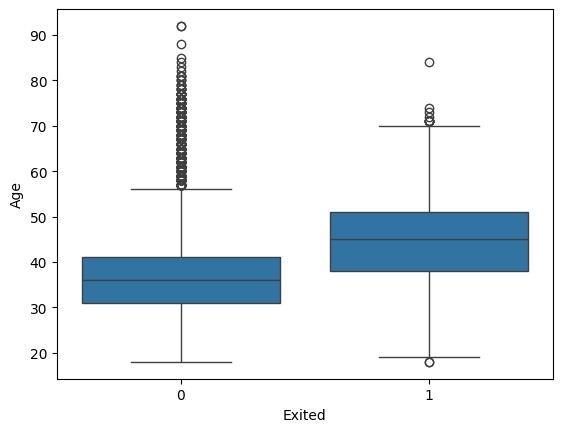

In [49]:
sns.boxplot(x="Exited", y="Age", data=df)

Как видно из графика, средний возраст клиентов, которые ушли, в среднем больше, чем у людей, которые остались в банке

<Axes: xlabel='Exited', ylabel='Balance'>

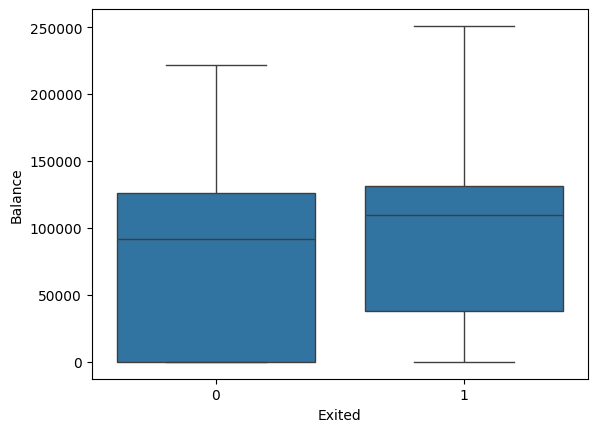

In [50]:
sns.boxplot(x="Exited", y="Balance", data=df)

Клиенты с большим остатком на счёте чаще уходят.

<Axes: xlabel='Exited', ylabel='CreditScore'>

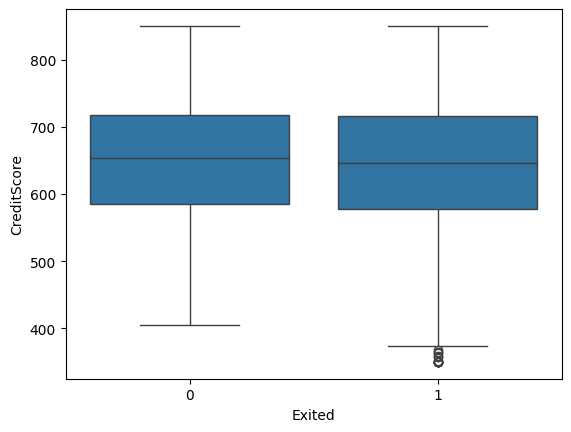

In [51]:
sns.boxplot(x="Exited", y="CreditScore", data=df)

Кредитный рейтинг практически никак не влияет на уход их банка.

<Axes: xlabel='Exited', ylabel='EstimatedSalary'>

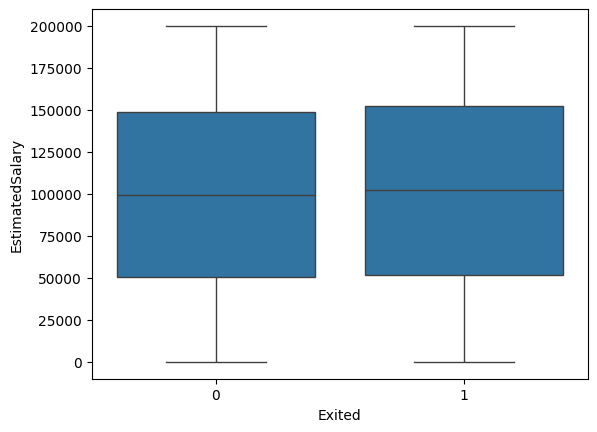

In [52]:
sns.boxplot(x='Exited', y='EstimatedSalary', data=df)

Оценённая зарплата почти никак не влияет на выход клиента

<Axes: xlabel='Geography'>

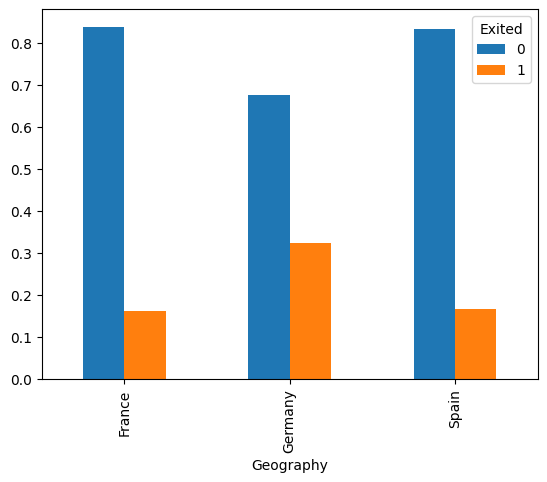

In [53]:
pd.crosstab(df["Geography"], df["Exited"], normalize="index").plot(kind="bar")

Отток клиентов существенно различается в зависимости от географического региона: немецкие клиенты уходят чаще всех, французские и испанские практически не отличаются. Таким образом, при data preprocessing можно закодировать France и Spain нулём, а Germany - единицей, перейдя к бинарному признаку.

<Axes: xlabel='IsActiveMember', ylabel='Exited'>

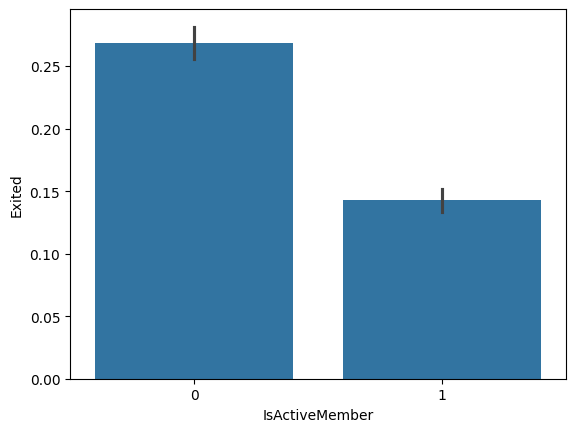

In [54]:
sns.barplot(x="IsActiveMember", y="Exited", data=df)

Активные участники уходят реже.

<Axes: xlabel='NumOfProducts', ylabel='Exited'>

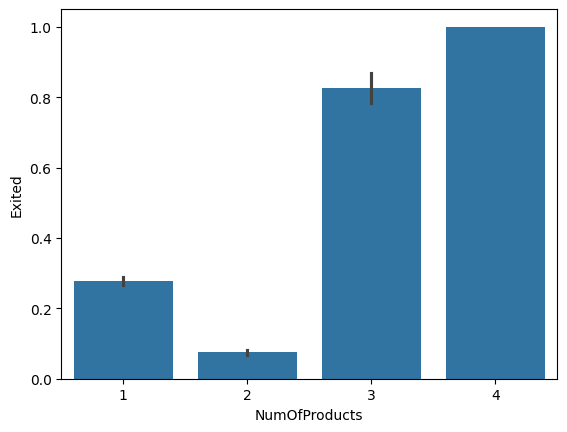

In [55]:
sns.barplot(x="NumOfProducts", y="Exited", data=df)

1 продукт - довольно высокий отток, 2 продукта - практически нет, 3 и 4 - очень странные аномалии (практически все клиенты расходятся).

<Axes: xlabel='Tenure', ylabel='Exited'>

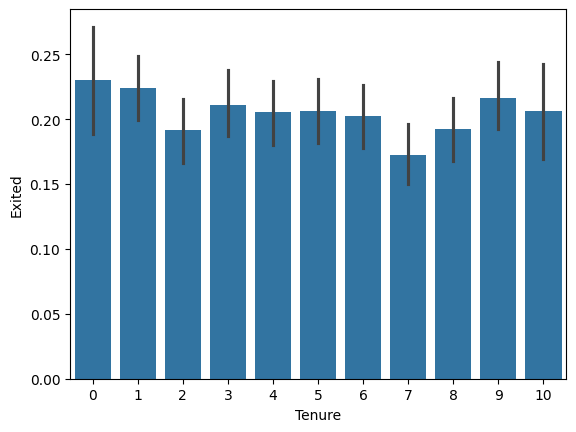

In [56]:
sns.barplot(x='Tenure', y='Exited', data=df)

Tenure слабо влияет на целевую переменную, но можно отметить, что самыми стабильными являются клиенты с Tenure = 3, 7, 8

<Axes: xlabel='HasCrCard', ylabel='Exited'>

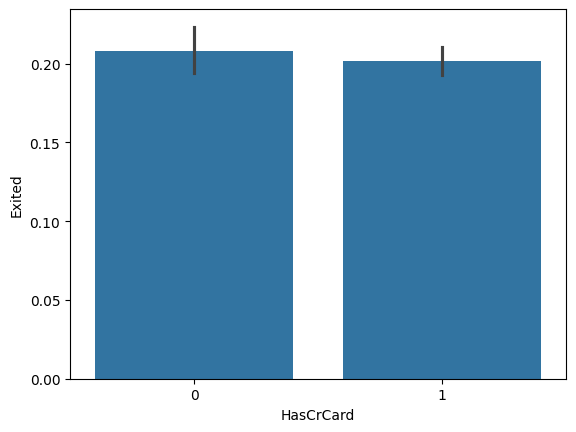

In [57]:
sns.barplot(x='HasCrCard', y='Exited', data=df)

Наличие кредитной карты почти не влияет на целевую переменную


<Axes: xlabel='Gender', ylabel='Exited'>

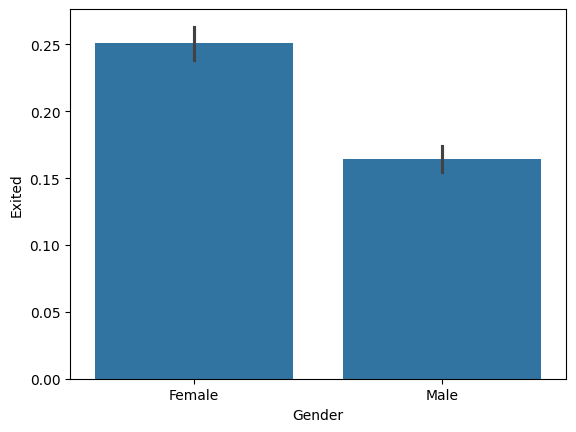

In [58]:
sns.barplot(x="Gender", y="Exited", data=df)

Как видно из графика, женщины чаще уходят.

<Axes: >

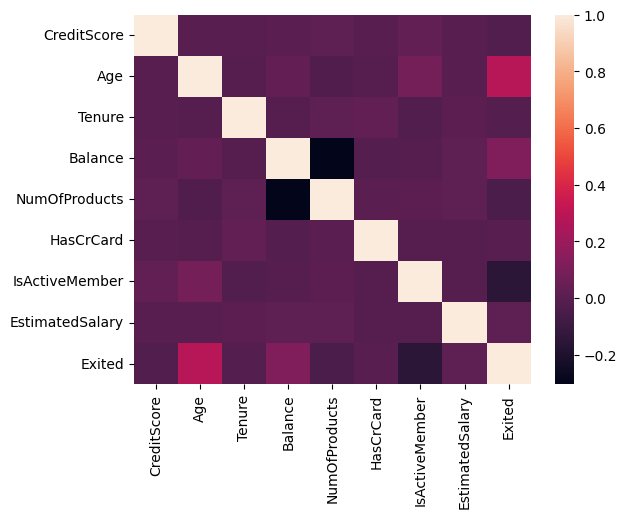

In [59]:
sns.heatmap(df.corr(numeric_only=True))

Как видно из тепловой карты коэффициентов корреляции Пирсона, Balance и NumOfProducts слабо коррелируют между собой, также наблюдается умеренная корреляция между целевой переменной Exited и признаком Age.

array([[<Axes: title={'center': 'CreditScore'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>],
       [<Axes: title={'center': 'Balance'}>,
        <Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>],
       [<Axes: title={'center': 'IsActiveMember'}>,
        <Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Exited'}>]], dtype=object)

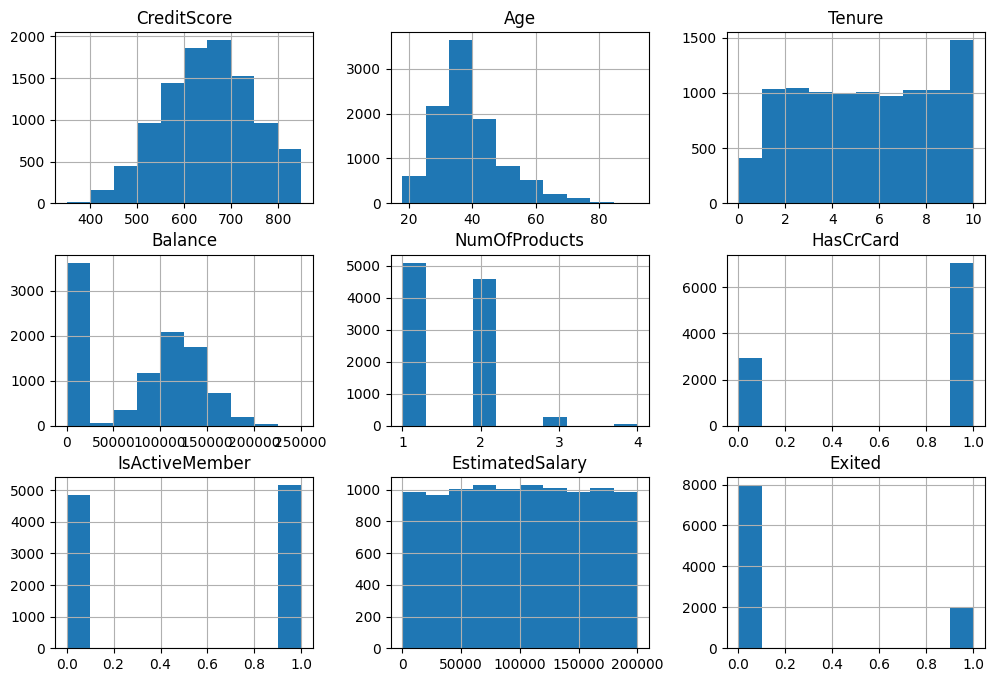

In [60]:
df.hist(figsize=(12, 8))

CreditScore распределён нормально с небольшим скосом вправо, Age - нормально со скосом влево, баланс - нормально при исключении баланса равного нулю.

In [61]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 10), (2000, 10), (8000,), (2000,))

In [63]:
X_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
2151,753,France,Male,57,7,0.00,1,1,0,159475.08
8392,739,Germany,Male,32,3,102128.27,1,1,0,63981.37
5006,755,Germany,Female,37,0,113865.23,2,1,1,117396.25
4117,561,France,Male,37,5,0.00,2,1,0,83093.25
7182,692,Germany,Male,49,6,110540.43,2,0,1,107472.99


In [64]:
categorical_features = [
    "Geography",
    "Gender"
]

numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

binary_features = [
    "HasCrCard",
    "IsActiveMember"
]

In [65]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    remainder="passthrough",
).set_output(transform="pandas")

# Logistic Regression

In [66]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight='balanced', random_state=42))
])

In [67]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"roc_auc: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}")

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

roc_auc: 0.7771762517525228


# Random Forest

In [68]:
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight='balanced', random_state=42))
])

In [69]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"roc_auc: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}")

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.42      0.55       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000

roc_auc: 0.8501853162870112


# XG Boost

In [70]:
from xgboost import XGBClassifier

In [71]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(scale_pos_weight=3.9, random_state=42))
])

In [72]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"roc_auc: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}")

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1593
           1       0.55      0.62      0.58       407

    accuracy                           0.82      2000
   macro avg       0.72      0.74      0.73      2000
weighted avg       0.83      0.82      0.82      2000

roc_auc: 0.829515185447389


# Light GBM

In [73]:
from lightgbm import LGBMClassifier

In [74]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(class_weight='balanced', random_state=42))
])

In [75]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"roc_auc: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}")

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
              precision    recall  f1-score   support

           0       0.92      0.83      0.88      1593
           1       0.53      0.72      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000

roc_auc: 0.8575185354846371


# Cat Boost

In [76]:
from catboost import CatBoostClassifier

In [77]:
# model = Pipeline([
#     ("preprocessor", preprocessor),
#     ("classifier", CatBoostClassifier(scale_pos_weight=3.9, verbose=0, random_state=42))
# ])

model = CatBoostClassifier(cat_features=['Geography', 'Gender'], auto_class_weights='Balanced', random_state=42, verbose=0)

In [78]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"roc_auc: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.83      0.88      1593
           1       0.53      0.72      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000

roc_auc: 0.8619297263365059
[[1327  266]
 [ 113  294]]


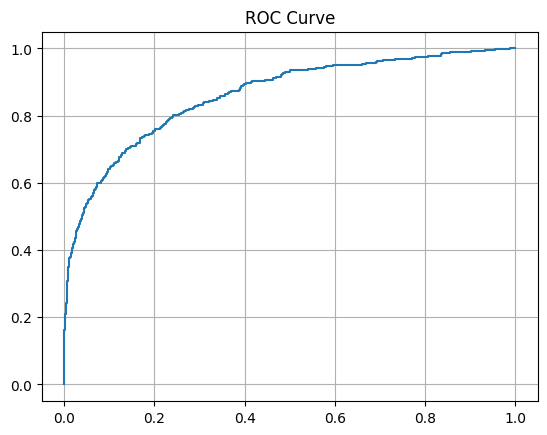

In [79]:
from sklearn.metrics import roc_curve

y_pred_proba = model.predict_proba(X_test)[:, -1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.grid()
plt.show()

In [80]:
import joblib
joblib.dump(model, '../models/catboost_bank_churn.joblib')

['../models/catboost_bank_churn.joblib']